[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/07-trustworthy-ai.ipynb)

# Trustworthy AI

**ELMED219 / BMED365 - Lab 3**

Last updated:<br>
2026-01-03, A. Lundervold

---

## Learning Objectives

After this notebook, you should be able to:
- Define what makes AI "trustworthy"
- Assess robustness and uncertainty in AI systems
- Describe the concept of "human-in-the-loop"
- Discuss validation and testing of medical AI
- Identify risks of AI drift (distributional shift)

## Contents

1. [What is Trustworthy AI?](#1-what-is-trustworthy-ai)
2. [Robustness](#2-robustness)
3. [Uncertainty Quantification](#3-uncertainty-quantification)
4. [Human-in-the-Loop](#4-human-in-the-loop)
5. [Validation and Testing](#5-validation-and-testing)
6. [Continuous Monitoring](#6-continuous-monitoring)

---

## 1. What is Trustworthy AI?

**Trustworthy AI** is AI that is worthy of trust - i.e., users can rely on the system to function as expected, be safe, and that decisions are fair and explainable.

### EU's Seven Requirements for Trustworthy AI

| Requirement | Description |
|------|-------------|
| **Human oversight** | Humans can override and control AI |
| **Robustness and safety** | The system is reliable and resilient |
| **Privacy** | Data is handled safely and in accordance with regulations |
| **Transparency** | Users understand how AI works |
| **Diversity and non-discrimination** | AI is fair for all groups |
| **Societal benefit** | AI contributes positively to society |
| **Accountability** | Clear accountability and possibility for complaint |

In [1]:
# Trustworthiness assessment

def assess_trustworthiness(system_info):
    """
    Simple assessment of AI system trustworthiness.
    """
    criteria = {
        "human_oversight": "Can humans override AI decisions?",
        "robustness": "Is the system tested for edge cases and errors?",
        "explainability": "Can decisions be explained to users?",
        "data_quality": "Are training data representative and of good quality?",
        "monitoring": "Is performance continuously monitored?",
        "fallback": "Is there a backup when AI fails?"
    }
    
    return criteria

print("TRUSTWORTHINESS CHECKLIST")
print("=" * 50)
for crit, question in assess_trustworthiness({}).items():
    print(f"\n{crit.replace('_', ' ').title()}:")
    print(f"  → {question}")

TRUSTWORTHINESS CHECKLIST

Human Oversight:
  → Can humans override AI decisions?

Robustness:
  → Is the system tested for edge cases and errors?

Explainability:
  → Can decisions be explained to users?

Data Quality:
  → Are training data representative and of good quality?

Monitoring:
  → Is performance continuously monitored?

Fallback:
  → Is there a backup when AI fails?


---

## 2. Robustness

A robust AI system handles:
- **Unexpected input**: Data that is different from training data
- **Adversarial attacks**: Deliberately manipulated input
- **System failures**: Network outages, hardware failures
- **Distributional shift**: Changes in data over time

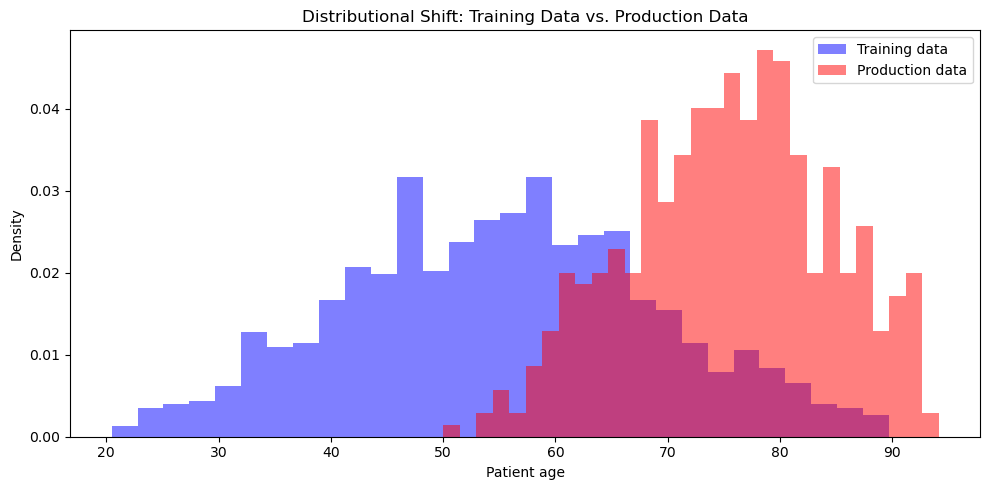


Consequence:
  - Training data: average 55.1 years
  - Production data: average 75.4 years
  - The model may perform worse on older patients
    because it has seen fewer such cases during training.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstration of distributional shift

def demonstrate_distributional_shift():
    """
    Shows how changes in data distribution can affect AI performance.
    """
    np.random.seed(42)
    
    # Training data: Patient age (typical hospital department)
    training_age = np.random.normal(55, 15, 1000)
    training_age = training_age[(training_age > 20) & (training_age < 90)]
    
    # Production data: Changed demographics (e.g., new geriatric department)
    production_age = np.random.normal(75, 10, 500)
    production_age = production_age[(production_age > 50) & (production_age < 95)]
    
    return training_age, production_age

training, production = demonstrate_distributional_shift()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(training, bins=30, alpha=0.5, label='Training data', color='blue', density=True)
ax.hist(production, bins=30, alpha=0.5, label='Production data', color='red', density=True)
ax.set_xlabel('Patient age')
ax.set_ylabel('Density')
ax.set_title('Distributional Shift: Training Data vs. Production Data')
ax.legend()
plt.tight_layout()
plt.show()

print("\nConsequence:")
print(f"  - Training data: average {training.mean():.1f} years")
print(f"  - Production data: average {production.mean():.1f} years")
print("  - The model may perform worse on older patients")
print("    because it has seen fewer such cases during training.")

---

## 3. Uncertainty Quantification

A trustworthy AI should be able to say "I am uncertain" when it is.

### Types of Uncertainty

| Type | Description | Can be reduced with |
|------|-------------|-------------------|
| **Epistemic** | Model uncertainty (lack of knowledge) | More data |
| **Aleatoric** | Inherent noise in the data | Not reducible |

In [4]:
# Demonstration of uncertainty in predictions

def simulate_prediction_with_uncertainty():
    """
    Simulates an AI model that provides uncertainty estimates.
    """
    patient_cases = [
        {"description": "Typical case, many similar in data", 
         "prediction": 0.85, "uncertainty": 0.05},
        {"description": "Unusual case, few similar in data",
         "prediction": 0.65, "uncertainty": 0.25},
        {"description": "Very rare condition",
         "prediction": 0.55, "uncertainty": 0.40}
    ]
    return patient_cases

cases = simulate_prediction_with_uncertainty()

print("PREDICTIONS WITH UNCERTAINTY")
print("=" * 60)

for i, case in enumerate(cases, 1):
    pred = case['prediction']
    unc = case['uncertainty']
    
    print(f"\nCase {i}: {case['description']}")
    print(f"  Prediction: {pred:.0%} ± {unc:.0%}")
    print(f"  Confidence interval: [{max(0, pred-unc):.0%}, {min(1, pred+unc):.0%}]")
    
    if unc > 0.20:
        print("  ⚠️  HIGH UNCERTAINTY - consider manual review")
    else:
        print("  ✓ Acceptable uncertainty")

PREDICTIONS WITH UNCERTAINTY

Case 1: Typical case, many similar in data
  Prediction: 85% ± 5%
  Confidence interval: [80%, 90%]
  ✓ Acceptable uncertainty

Case 2: Unusual case, few similar in data
  Prediction: 65% ± 25%
  Confidence interval: [40%, 90%]
  ⚠️  HIGH UNCERTAINTY - consider manual review

Case 3: Very rare condition
  Prediction: 55% ± 40%
  Confidence interval: [15%, 95%]
  ⚠️  HIGH UNCERTAINTY - consider manual review


---

## 4. Human-in-the-Loop

**Human-in-the-loop** (HITL) means that humans are involved in the AI decision-making process.

### Three Levels

```
HUMAN-IN-THE-LOOP
  └── Human approves EVERY decision
  └── High control, low efficiency

HUMAN-ON-THE-LOOP
  └── Human monitors and can intervene
  └── Balanced approach

HUMAN-OUT-OF-THE-LOOP
  └── Full automation
  └── High efficiency, low control
  └── NOT recommended for medical AI
```

In [5]:
# Example of HITL workflow

def hitl_workflow(ai_prediction, confidence_threshold=0.80):
    """
    Demonstrates a human-in-the-loop workflow.
    """
    prediction = ai_prediction['prediction']
    confidence = ai_prediction['confidence']
    
    print("AI-SUPPORTED DECISION PROCESS")
    print("=" * 50)
    print(f"AI prediction: {prediction}")
    print(f"AI confidence: {confidence:.0%}")
    print()
    
    if confidence >= confidence_threshold:
        print("→ HIGH CONFIDENCE")
        print("  Recommendation presented to physician for confirmation.")
        print("  Physician can approve or override.")
        return "AUTOMATIC WITH CONFIRMATION"
    else:
        print("→ LOW CONFIDENCE")
        print("  Flagged for MANUAL REVIEW.")
        print("  Physician must make independent assessment.")
        print("  AI prediction shown as one of several inputs.")
        return "MANUAL REVIEW REQUIRED"

# Test with two scenarios
print("\n" + "="*60 + "\n")
print("SCENARIO 1:")
hitl_workflow({"prediction": "High risk of DVT", "confidence": 0.92})

print("\n" + "="*60 + "\n")
print("SCENARIO 2:")
hitl_workflow({"prediction": "Possible pneumonia", "confidence": 0.65})



SCENARIO 1:
AI-SUPPORTED DECISION PROCESS
AI prediction: High risk of DVT
AI confidence: 92%

→ HIGH CONFIDENCE
  Recommendation presented to physician for confirmation.
  Physician can approve or override.


SCENARIO 2:
AI-SUPPORTED DECISION PROCESS
AI prediction: Possible pneumonia
AI confidence: 65%

→ LOW CONFIDENCE
  Flagged for MANUAL REVIEW.
  Physician must make independent assessment.
  AI prediction shown as one of several inputs.


'MANUAL REVIEW REQUIRED'

---

## 5. Validation and Testing

Before a medical AI system is put into use, it must undergo comprehensive testing.

### Testing Strategies

1. **Retrospective validation**: Test on historical data
2. **Prospective validation**: Test on new patients (study)
3. **External validation**: Test on data from other institutions
4. **Subgroup analysis**: Test on different patient groups
5. **Stress testing**: Test with edge cases and adversarial input

---

## 6. Continuous Monitoring

AI systems must be monitored after implementation to catch:

- **Performance degradation**: Declining accuracy over time
- **Distributional shift**: Changes in patient population
- **Error patterns**: Systematic errors on specific groups
- **User behavior**: How physicians actually use the system

---

## Summary

### Key Points

1. **Trustworthy AI** fulfills seven requirements: control, robustness, privacy, transparency, fairness, societal benefit, accountability
2. **Robustness** means the system handles unexpected situations
3. **Uncertainty quantification** allows AI to say "I don't know"
4. **Human-in-the-loop** ensures human control
5. **Continuous monitoring** catches problems after implementation

### Reflection Questions

1. How would you design a system that flags AI predictions requiring manual review?
2. What metrics would you monitor for an AI system at your future workplace?

---

*Next notebook: [08 - Neurosymbolic AI](08-neurosymbolic-ai.ipynb)*